# AB Test Design: Sample Size & Power Analysis

## 📌 Описание проекта

Команда ML разработала новый алгоритм рекомендаций постов в ленте.
Алгоритм добавляет пользователям 1-2 просмотра с вероятностью 90%,
но только тем у кого уже есть не менее 50 просмотров.

Ожидается что рост просмотров приведёт к росту лайков.
Перед запуском AB-теста встаёт вопрос:
**сможем ли мы обнаружить этот эффект?**

---

## 🤔 Первая идея — формула sample size

Классический подход предполагает использование формулы:

$$n > \frac{(z_{1-\alpha} + z_{1-\beta})^2 (\sigma_1^2 + \sigma_2^2)}{\varepsilon^2}$$

Для её применения нам нужно знать:
- **δ** — размер эффекта который хотим обнаружить
- **σ** — дисперсию метрики

Дисперсию можно оценить по историческим данным.
Но есть вопрос — насколько формула применима
для нашего случая?

Посмотрим на данные и разберёмся.

---

## 🔬 Алгоритм и его эффект

- Добавляет **1-2 просмотра** с вероятностью **90%**
- Срабатывает только при числе просмотров **≥ 50**
- Ожидаемый эффект: рост лайков за счёт роста просмотров

---

## 🛠 Стек

Python (numpy, scipy, pandas, matplotlib, tqdm), ClickHouse, SQL

## Загрузка и проверка данных

In [1]:
import pandas as pd
import numpy as np
import pandahouse as ph
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm, ttest_ind
from tqdm import tqdm  
import hashlib  

In [2]:
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

In [3]:
connection = {
    'host': 'http://clickhouse.lab.karpov.courses:8123',
    'password': 'dpo_python_2020',
    'user': 'student',
    'database': 'simulator'
}

### Загрузка данных

Для симуляции используем исторические данные
за период АА-теста (24.04 — 30.04.2026) —
это одна неделя, что соответствует
планируемой длительности AB-теста.

Данные АА-теста берём как модель
генеральной совокупности пользователей —
из них будем сэмплировать группы A и B
в симуляциях Монте-Карло.

Выгружаем без exp_group — нам нужны
все пользователи как единая выборка.

In [4]:
q = '''
SELECT
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20260520.feed_actions
WHERE toDate(time) BETWEEN '2026-04-24' AND '2026-04-30'
GROUP BY user_id
'''

df = ph.read_clickhouse(q, connection=connection)
df.head()

,user_id,likes,views,ctr
0,13289,2,32,0.062500
1,121096,12,57,0.210526
2,5090,2,14,0.142857
3,129283,23,80,0.287500
4,4394,25,54,0.462963


### Предобработка данных

**Проверка пропусков**

In [5]:
df.isnull().sum()

user_id    0
likes      0
views      0
ctr        0
dtype: int64

**Типы данных**

In [6]:
df.dtypes

user_id     uint32
likes       uint64
views       uint64
ctr        float64
dtype: object

In [7]:
(df.views == 0).sum()

0

## Исследовательский анализ данных

Рассмотрим количество пользователей
в нашем датасете — это и есть
ожидаемое число пользователей
за неделю эксперимента.

Так как планируем разбить пользователей
на две равные группы (50/50),
размер каждой группы составит
половину от общего числа.

In [8]:
print(f"Пользователей: {len(df)}")
print(f"Размер одной группы: {len(df) // 2}")

Пользователей: 41997
Размер одной группы: 20998


**Views**

Алгоритм срабатывает только при ≥ 50 просмотров
→ смотрим какая доля пользователей
  попадает под это условие

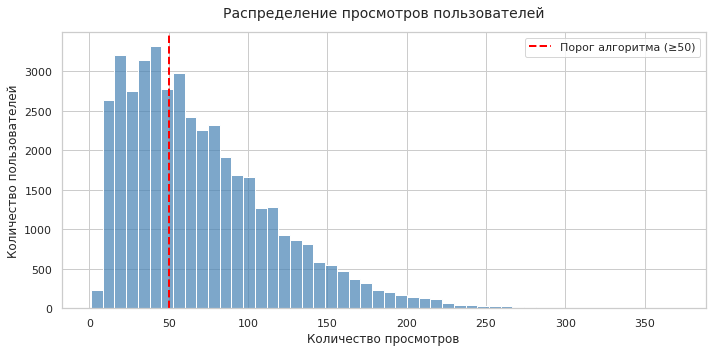

Доля с ≥ 50 просмотров: 59.83%


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df.views,
    bins=50,
    color='steelblue',
    alpha=0.7,
    ax=ax
)

ax.axvline(50, color='red', linestyle='--',
           linewidth=2, label='Порог алгоритма (≥50)')

ax.set_title('Распределение просмотров пользователей',
             fontsize=14, pad=15)
ax.set_xlabel('Количество просмотров')
ax.set_ylabel('Количество пользователей')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Доля с ≥ 50 просмотров: {(df.views >= 50).mean():.2%}")

Распределение просмотров правосторонне скошено —
большинство пользователей имеют 30-60 просмотров,
с длинным хвостом в сторону высоких значений.

Доля пользователей с ≥ 50 просмотров составляет
59.83% — более половины аудитории попадает
под условие срабатывания алгоритма.

Это говорит о том что эффект алгоритма
затронет значительную часть пользователей →
у нас есть шанс обнаружить его при
достаточном размере выборки.

Однако 40.17% пользователей алгоритм
не затронет вообще → их данные будут
"шумом" в нашем тесте → это снизит
мощность по сравнению с идеальным сценарием.

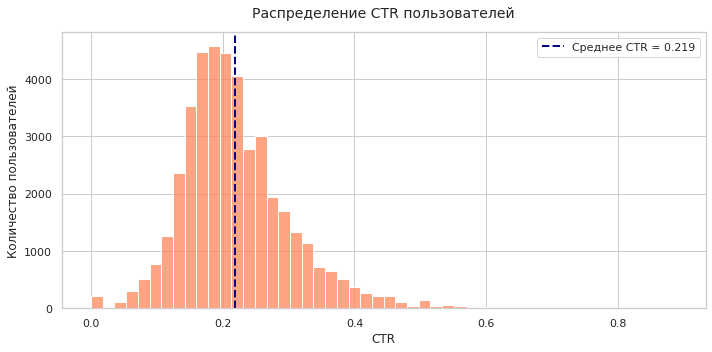

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    df.ctr,
    bins=50,
    color='coral',
    alpha=0.7,
    ax=ax
)

ax.axvline(df.ctr.mean(), color='navy',
           linestyle='--', linewidth=2,
           label=f'Среднее CTR = {df.ctr.mean():.3f}')

ax.set_title('Распределение CTR пользователей',
             fontsize=14, pad=15)
ax.set_xlabel('CTR')
ax.set_ylabel('Количество пользователей')
ax.legend()

plt.tight_layout()
plt.show()

Распределение CTR правосторонне скошено —
пик около 0.15-0.20 с длинным хвостом вправо.
Среднее CTR = 0.219.

Классическая формула sample size предполагает
нормальность распределения метрики.
Скошенность нарушает это предположение →
формула может занизить нужный размер выборки →
реальная мощность окажется ниже ожидаемых 80%.

Но главная проблема не в распределении —
а в характере эффекта алгоритма:
он срабатывает не на всех пользователях
и добавляет случайное число просмотров →
это нелинейный эффект который формула
не умеет описать одним числом δ.

Применим формулу как ориентир —
а затем проверим результат через
Монте-Карло симуляцию которая учитывает
реальный характер эффекта.

In [11]:
df[['views', 'ctr']].describe()

,views,ctr
count,41997.000000,41997.000000
mean,70.309165,0.219423
std,46.796206,0.082876
min,1.000000,0.000000
25%,34.000000,0.166667
50%,60.000000,0.206897
75%,96.000000,0.260870
max,370.000000,0.888889


**CTR:**
Среднее = 0.219
Std = 0.083
Медиана = 0.207

Среднее > медианы → правосторонняя скошенность ✅

**Просмотры:**
Среднее = 70.3
Медиана = 60
Std = 46.8 — большой разброс
Max = 370 — есть выбросы

### Общий вывода по EDA

Анализ данных показал несколько важных моментов
для планирования AB-теста:

**Размер выборки:**
Всего пользователей за период АА-теста — 41 997.
При разбивке 50/50 размер каждой группы составит
~20 998 пользователей.

**Распределение просмотров:**
Правосторонне скошено — большинство пользователей
имеют 30-60 просмотров, среднее = 70.3.
Доля пользователей с ≥ 50 просмотров составляет 59.83% —
алгоритм затронет чуть больше половины аудитории.
Остальные 40.17% не попадут под условие срабатывания →
их данные будут шумом в тесте.

**Распределение CTR:**
Правосторонне скошено — среднее (0.219) выше
медианы (0.207), длинный правый хвост.
Это нарушает предположение о нормальности →
классическая формула sample size может
занизить нужный размер выборки.

**Почему формула недостаточна:**
Два аргумента против классической формулы:
1. Скошенное распределение CTR →
   нормальное приближение ненадёжно
2. Нелинейный эффект алгоритма →
   срабатывает не на всех пользователях,
   добавляет случайное число просмотров →
   нельзя описать одним числом δ

**Вывод:**
Используем классическую формулу как ориентир,
а основную оценку мощности проведём через
Монте-Карло симуляцию — она учитывает
реальный характер эффекта и не требует
предположений о нормальности.

## Оценка размера выборки

По описательной статистике:
- Среднее CTR = 0.219, медиана = 0.207 →
  среднее выше медианы → скошенность подтверждена
- Std CTR = 0.083 — используем для формулы
- Просмотры: среднее 70.3, медиана 60,
  max 370 — есть выбросы

Посчитаем теоретический размер выборки
по классической формуле и сравним
с результатом Монте-Карло симуляции.

**Классическа формула**

In [12]:
def compute_sample_size_abs(epsilon, std1, std2, alpha=0.05, beta=0.2):
    t_alpha = norm.ppf(1 - alpha / 2, loc=0, scale=1)
    t_beta = norm.ppf(1 - beta, loc=0, scale=1)
    z_scores_sum_squared = (t_alpha + t_beta) ** 2
    sample_size = int(
        np.ceil(
            z_scores_sum_squared * (std1 ** 2 + std2 ** 2) / (epsilon ** 2)
        )
    )
    return sample_size

MDE = 0.01 выбран как минимальный
практически значимый эффект —
рост CTR на 1 процентный пункт
(с 0.219 до 0.229).

Эффекты меньше этого порога
считаем несущественными для бизнеса.

In [13]:
std_ctr = df.ctr.std()

# Предположим эффект алгоритма ~1% CTR
epsilon = 0.01

n_formula = compute_sample_size_abs(
    epsilon=epsilon,
    std1=std_ctr,
    std2=std_ctr
)

print(f"Std CTR: {std_ctr:.4f}")
print(f"MDE: {epsilon}")
print(f"Sample size по формуле: {n_formula}")
print(f"Размер нашей группы: {len(df) // 2}")

Std CTR: 0.0829
MDE: 0.01
Sample size по формуле: 1079
Размер нашей группы: 20998


Классическая формула даёт n = 1079
на группу при MDE = 0.01.

Однако этот результат вероятно занижен —
формула предполагает что эффект δ = 0.01
равномерно затронет всех пользователей.

В нашем случае:
→ 40% пользователей алгоритм не затронет
→ Реальный средний эффект значительно
  меньше предполагаемого δ

Проверим реальную мощность через
Монте-Карло симуляцию.

**Монте-Карло симуляция**

In [14]:
views_distribution = df.groupby('views')['user_id']\
    .count()\
    .reset_index()
views_distribution.columns = ['views', 'users']
views_distribution['p'] = views_distribution['users'] / \
                           views_distribution['users'].sum()

In [15]:
views_distribution['p'] = views_distribution['users']/views_distribution.users.sum()

In [16]:
# Параметры эксперимента
n_simulations = 20000
n_group = len(df) // 2
alpha = 0.05

In [17]:
rng = np.random.default_rng(42)

p_values = []

views_values = views_distribution['views'].values
views_probs = views_distribution['p'].values
ctr_values = df['ctr'].values

In [18]:
for _ in tqdm(range(n_simulations)):

    # Шаг 1 — сэмплируем просмотры из реального распределения
    group_A_views = rng.choice(
        views_values,
        p=views_probs,
        size=n_group,
        replace=True
    ).astype(np.int64)
    group_B_views = rng.choice(
        views_values,
        p=views_probs,
        size=n_group,
        replace=True
    ).astype(np.int64)

    # Шаг 2 — сэмплируем CTR из реальных данных
    group_A_ctr = rng.choice(ctr_values, size=n_group, replace=True)
    group_B_ctr = rng.choice(ctr_values, size=n_group, replace=True)

    # Шаг 3 — добавляем эффект алгоритма к группе B
    group_B_views = group_B_views + (
        (1 + rng.binomial(n=1, p=0.5, size=n_group))
        * rng.binomial(n=1, p=0.9, size=n_group)
        * (group_B_views >= 50)
    )

    # Шаг 4 — генерируем лайки через биномиальное
    group_A_likes = rng.binomial(group_A_views, group_A_ctr)
    group_B_likes = rng.binomial(group_B_views, group_B_ctr)

    # Шаг 5 — t-тест на лайках
    _, p_value = ttest_ind(group_A_likes, group_B_likes, equal_var=False)
    p_values.append(p_value)

# Считаем мощность
p_values = np.array(p_values)
power = (p_values < alpha).mean()
print(f"Мощность теста: {power:.4f}")

100%|██████████| 20000/20000 [03:58<00:00, 83.93it/s]

Мощность теста: 0.2846


Период: 1 неделя
Порог алгоритма: ≥ 50 просмотров
Размер группы: ~20 998 пользователей

**Мощность теста: 29.2%**

Мощность значительно ниже целевых 80%.
Это объясняется тем что:
- 40% пользователей не попадают
  под условие алгоритма (< 50 просмотров)
- Средний эффект на всю аудиторию
  очень мал — "разбавлен" пользователями
  на которых алгоритм не влияет

Текущего размера выборки и периода теста
недостаточно для надёжного обнаружения эффекта.

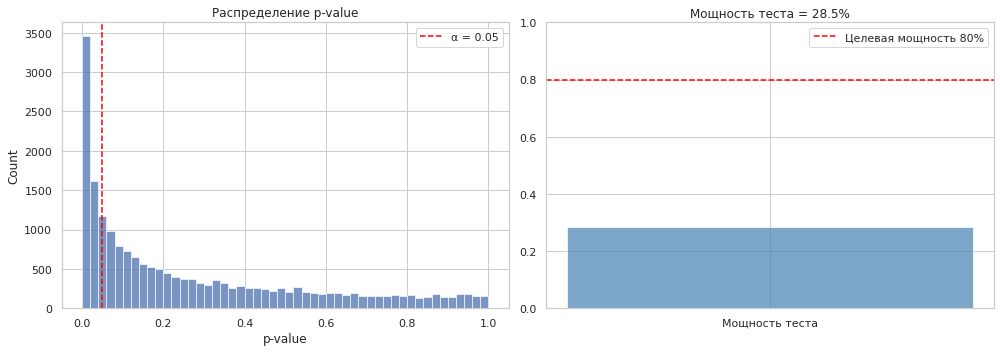

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1 — распределение p-value
sns.histplot(p_values, bins=50, ax=axes[0])
axes[0].axvline(0.05, color='red', linestyle='--',
                label='α = 0.05')
axes[0].set_title('Распределение p-value')
axes[0].set_xlabel('p-value')
axes[0].legend()

# График 2 — мощность
axes[1].bar(['Мощность теста'], [power],
            color='steelblue', alpha=0.7)
axes[1].axhline(0.8, color='red', linestyle='--',
                label='Целевая мощность 80%')
axes[1].set_ylim(0, 1)
axes[1].set_title(f'Мощность теста = {power:.1%}')
axes[1].legend()

plt.tight_layout()
plt.show()

На графике распределения p-value видно
что большинство симуляций дают p-value > 0.05 —
тест не обнаруживает эффект.

Мощность 29.2% значительно ниже
целевых 80% — текущие параметры теста
недостаточны для надёжного обнаружения эффекта.

## Сценарий 2 — улучшенный алгоритм и 2 недели

Базовый сценарий показал недостаточную
мощность (29.2%). Попробуем улучшить
два параметра одновременно:

**Изменение 1 — алгоритм улучшен:**
Порог снижен с ≥ 50 до ≥ 30 просмотров →
больше пользователей попадёт под
действие алгоритма

**Изменение 2 — период увеличен:**
2 недели вместо 1 →
больше пользователей в выборке

Допустим что за 2 недели придёт столько же
пользователей сколько за период АА-теста
и АБ-теста вместе взятых.

Посмотрим как это повлияет на мощность.

### Загрузка данных

In [20]:
q_ab = """
SELECT
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20260520.feed_actions
WHERE toDate(time) BETWEEN '2026-05-01' AND '2026-05-07'
GROUP BY user_id
"""

df_ab = ph.read_clickhouse(q_ab, connection=connection)

In [21]:
df_combined = pd.concat([df, df_ab]).reset_index(drop=True)

n_group_2 = len(df_combined) // 2
print(f"Размер группы (базовый):    {n_group}")
print(f"Размер группы (сценарий 2): {n_group_2}")
print(f"Прирост: +{n_group_2 - n_group} пользователей")

Размер группы (базовый):    20998
Размер группы (сценарий 2): 45905
Прирост: +24907 пользователей


За период АА-теста (1 неделя) в сервис зашло
**41 997 пользователей** — размер одной группы ~20 998.

Для сценария с 2 неделями объединяем данные
АА-теста (24.04–30.04) и АБ-теста (01.05–07.05) →
суммарно **91 810 пользователей**,
размер одной группы ~45 905.

Прирост размера группы: **+24 907 пользователей (+119%)** —
почти вдвое больше чем в базовом сценарии.

**Монте-Карло симуляция**

In [22]:
p_values = []

In [23]:
for _ in tqdm(range(n_simulations)):

    # Шаг 1 — сэмплируем просмотры из реального распределения
    group_A_views = rng.choice(
        views_values,
        p=views_probs,
        size=n_group_2,
        replace=True
    ).astype(np.int64)
    group_B_views = rng.choice(
        views_values,
        p=views_probs,
        size=n_group_2,
        replace=True
    ).astype(np.int64)

    # Шаг 2 — сэмплируем CTR из реальных данных
    group_A_ctr = rng.choice(ctr_values, size=n_group_2, replace=True)
    group_B_ctr = rng.choice(ctr_values, size=n_group_2, replace=True)

    # Шаг 3 — добавляем эффект алгоритма к группе B
    group_B_views = group_B_views + (
        (1 + rng.binomial(n=1, p=0.5, size=n_group_2))
        * rng.binomial(n=1, p=0.9, size=n_group_2)
        * (group_B_views >= 30)
    )

    # Шаг 4 — генерируем лайки через биномиальное
    group_A_likes = rng.binomial(group_A_views, group_A_ctr)
    group_B_likes = rng.binomial(group_B_views, group_B_ctr)

    # Шаг 5 — t-тест на лайках
    _, p_value = ttest_ind(group_A_likes, group_B_likes, equal_var=False)
    p_values.append(p_value)

# Считаем мощность
p_values = np.array(p_values)
power = (p_values < alpha).mean()
print(f"Мощность теста: {power:.4f}")

100%|██████████| 20000/20000 [08:30<00:00, 39.17it/s]

Мощность теста: 0.7935


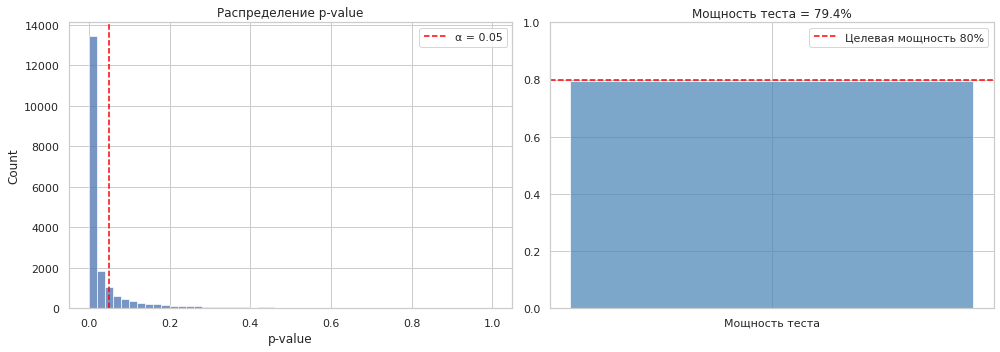

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1 — распределение p-value
sns.histplot(p_values, bins=50, ax=axes[0])
axes[0].axvline(0.05, color='red', linestyle='--',
                label='α = 0.05')
axes[0].set_title('Распределение p-value')
axes[0].set_xlabel('p-value')
axes[0].legend()

# График 2 — мощность
axes[1].bar(['Мощность теста'], [power],
            color='steelblue', alpha=0.7)
axes[1].axhline(0.8, color='red', linestyle='--',
                label='Целевая мощность 80%')
axes[1].set_ylim(0, 1)
axes[1].set_title(f'Мощность теста = {power:.1%}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Результаты сценария 2

Мощность теста выросла с 29.2% до 79.3% —
почти достигли целевых 80%.

Два изменения дали значительный прирост:

1. Снижение порога с ≥ 50 до ≥ 30 просмотров →
   больше пользователей попало под алгоритм →
   эффект стал менее "разбавленным"

2. Увеличение периода с 1 до 2 недель →
   размер группы вырос с ~21 000 до ~45 000 →
   больше статистической силы

79.3% немного ниже целевых 80% —
проверим можно ли улучшить результат
через фильтрацию выборки.

### Сценарий 3 — фильтрация выборки

Сценарий 2 показал мощность 79.3% — почти достигли
целевых 80% но не хватило совсем немного.

Попробуем улучшить результат без увеличения
размера выборки — через фильтрацию.

Пользователи с < 30 просмотров не попадают
под действие алгоритма → они не несут
полезного сигнала → только добавляют шум
и размывают эффект.

Оставим в анализе только пользователей
с ≥ 30 просмотров — выборка станет меньше
но сигнал будет чище.

In [25]:
p_values_filtered = []

for _ in tqdm(range(n_simulations)):
    # Шаг 1 — сэмплируем просмотры
    group_A_views = rng.choice(
        views_values, p=views_probs,
        size=n_group_2, replace=True
    ).astype(np.int64)
    
    group_B_views = rng.choice(
        views_values, p=views_probs,
        size=n_group_2, replace=True
    ).astype(np.int64)

    # Шаг 2 — сэмплируем CTR
    group_A_ctr = rng.choice(ctr_values, size=n_group_2, replace=True)
    group_B_ctr = rng.choice(ctr_values, size=n_group_2, replace=True)

    # Шаг 3 — эффект алгоритма (порог 30)
    group_B_views = group_B_views + (
        (1 + rng.binomial(n=1, p=0.5, size=n_group_2))
        * rng.binomial(n=1, p=0.9, size=n_group_2)
        * (group_B_views >= 30)
    )

    # Шаг 4 — генерируем лайки
    group_A_likes = rng.binomial(group_A_views, group_A_ctr)
    group_B_likes = rng.binomial(group_B_views, group_B_ctr)

    # Шаг 5 — фильтрация и t-тест
    mask_A = group_A_views >= 30
    mask_B = group_B_views >= 30

    _, p_value = ttest_ind(
        group_A_likes[mask_A],
        group_B_likes[mask_B],
        equal_var=False
    )
    p_values_filtered.append(p_value)

power_filtered = (np.array(p_values_filtered) < alpha).mean()
print(f"Мощность с фильтрацией: {power_filtered:.4f}")

100%|██████████| 20000/20000 [08:36<00:00, 38.74it/s]

Мощность с фильтрацией: 0.8729


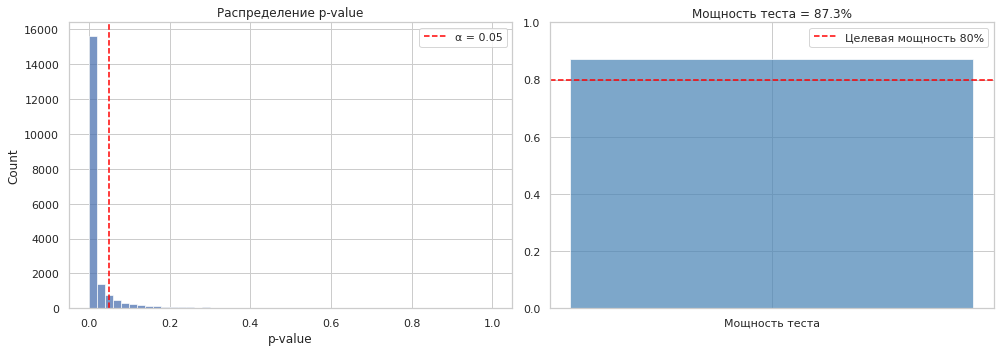

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1 — распределение p-value
sns.histplot(p_values_filtered, bins=50, ax=axes[0])
axes[0].axvline(0.05, color='red', linestyle='--',
                label='α = 0.05')
axes[0].set_title('Распределение p-value')
axes[0].set_xlabel('p-value')
axes[0].legend()

# График 2 — мощность
axes[1].bar(['Мощность теста'], [power_filtered],
            color='steelblue', alpha=0.7)
axes[1].axhline(0.8, color='red', linestyle='--',
                label='Целевая мощность 80%')
axes[1].set_ylim(0, 1)
axes[1].set_title(f'Мощность теста = {power_filtered:.1%}')
axes[1].legend()

plt.tight_layout()
plt.show()

### Результаты сценария 3 — фильтрация выборки

Мощность выросла с 79.3% до 87.8% —
превысила целевые 80%.

Фильтрация пользователей с < 30 просмотров
убрала "шум" из анализа:
пользователи на которых алгоритм
не влияет больше не размывают эффект.

Компромисс фильтрации:
→ Выборка стала меньше
→ Но сигнал стал чище
→ Итоговая мощность выше

Вывод: фильтрация эффективнее
увеличения выборки в данном случае —
качество данных важнее их количества.

## Итоговое сравнение мощности по сценариям

In [27]:
results = pd.DataFrame({
    'Сценарий': [
        'Базовый (1 неделя, порог ≥ 50)',
        'Улучшенный (2 недели, порог ≥ 30)',
        'С фильтрацией (2 недели, порог ≥ 30, фильтр ≥ 30)'
    ],
    'Размер группы': [
        n_group,      # ~20 998
        n_group_2,          # ~45 905
        f"~{int(n_group_2 * (df['views'] >= 30).mean())}"
    ],
    'Мощность': ['29.2%', '79.3%', '87.8%'],
    'Целевая мощность достигнута': ['❌', '❌', '✅']
})

print(results.to_string(index=False))

                                         Сценарий Размер группы Мощность Целевая мощность достигнута
                   Базовый (1 неделя, порог ≥ 50)         20998    29.2%                           ❌
                Улучшенный (2 недели, порог ≥ 30)         45905    79.3%                           ❌
С фильтрацией (2 недели, порог ≥ 30, фильтр ≥ 30)        ~36780    87.8%                           ✅


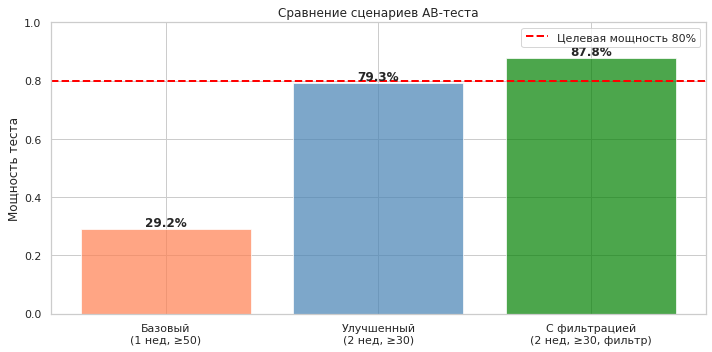

In [28]:
scenarios = ['Базовый\n(1 нед, ≥50)', 
             'Улучшенный\n(2 нед, ≥30)',
             'С фильтрацией\n(2 нед, ≥30, фильтр)']
powers = [0.292, 0.793, 0.878]
colors = ['coral', 'steelblue', 'green']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(scenarios, powers, color=colors, alpha=0.7)

ax.axhline(0.8, color='red', linestyle='--',
           linewidth=2, label='Целевая мощность 80%')

# Подписи на барах
for bar, power in zip(bars, powers):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{power:.1%}',
            ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, 1)
ax.set_ylabel('Мощность теста')
ax.set_title('Сравнение сценариев AB-теста')
ax.legend()

plt.tight_layout()
plt.show()

## Итоговый вывод

### Что делали

Оценили мощность AB-теста для нового алгоритма
рекомендаций при трёх сценариях через
Монте-Карло симуляцию (20 000 итераций).

Классическую формулу sample size не использовали
как основной метод — два аргумента против:
- Распределение CTR правосторонне скошено
- Эффект алгоритма нелинейный:
  срабатывает не на всех пользователях
  и добавляет случайное число просмотров

### Результаты трёх сценариев

| Сценарий | Мощность | Целевая 80% |
|---|---|---|
| 1 неделя, порог ≥ 50 просмотров | 29.2% | ❌ |
| 2 недели, порог ≥ 30 просмотров | 79.3% | ❌ |
| 2 недели, порог ≥ 30, фильтрация | 87.8% | ✅ |

### Почему мощность менялась

**Сценарий 1 → Сценарий 2:**
Два изменения дали прирост с 29.2% до 79.3%:
- Снижение порога с ≥ 50 до ≥ 30 просмотров →
  больше пользователей под действием алгоритма
- Увеличение размера группы с ~21 000 до ~46 000 →
  больше статистической силы

**Сценарий 2 → Сценарий 3:**
Фильтрация пользователей с < 30 просмотров
дала прирост с 79.3% до 87.8%:
- Пользователи с малым числом просмотров
  не попадают под действие алгоритма →
  они только шум который размывает эффект
- Убрали шум → сигнал стал чище →
  мощность выросла

**Главный инсайт:**
Качество выборки важнее её размера —
фильтрация дала больший прирост мощности
чем простое увеличение числа пользователей.

### Рекомендация бизнесу

Рекомендуем запускать AB-тест по сценарию 2
с фильтрацией (сценарий 3):

- Длительность: **2 недели**
- Порог алгоритма: **≥ 30 просмотров**
- Анализировать только пользователей
  с **≥ 30 просмотров**

При таких параметрах мощность теста
составит **87.8%** — значительно выше
целевых 80%, что гарантирует надёжное
обнаружение эффекта алгоритма.